In [7]:
import pdfplumber
import pandas as pd
import re
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    cohen_kappa_score,
    root_mean_squared_error,
)
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
DATA_PATH = "./Data.pdf"
CSV_PATH_GPT4 = "../risultati/AETERNA/risultati_eval_GPT4.1.csv"
# CSV_PATH = "../risultati/nuovi_risultati_eval.csv"
# CSV_PATH_2 = "../risultati/nuovi_risultati_eval.csv"
# CSV_PATH_2 = "../risultati/SemSim_nuovi_risultati_eval.csv"
CSV_PATH_GPT5 = "../risultati/risultati_eval_5-mini.csv"
RIPROVA = "../risultati.csv"
METRICS = [
    "Faithfulness",
    "Answer_Relevancy",
    "Context_Precision",
    "Context_Recall",
    "Noise_Sensitivity",
    "Semantic_Similarity",
    "Answer_Correctness",
]

In [9]:

def extract_values(pdf_path):
    results = []
    with pdfplumber.open(pdf_path) as pdf:
        full_text = "".join([page.extract_text() + "\n" for page in pdf.pages])
    questions = re.split(r"Question \d+:", full_text)

    for i in range(1, len(questions)):
        content = questions[i]
        domanda_text = content.split("Ground Truth:")[0].strip()
        metrics = {
            "ID": i,
            "Question": domanda_text,
            "Faithfulness": get_metric(r"Faithfulness[\s\S]*?(\d\.\d+)", content),
            "Answer_Relevancy": get_metric(
                r"Answer Relevancy[\s\S]*?(\d\.\d+)", content
            ),
            "Context_Precision": get_metric(
                r"Context Precision[\s\S]*?(\d\.\d+)", content
            ),
            "Context_Recall": get_metric(r"Context Recall[\s\S]*?(\d\.\d+)", content),
            "Noise_Sensitivity": get_metric(
                r"Noise Sensitivity[\s\S]*?(\d\.\d+)", content
            ),
            "Semantic_Similarity": get_metric(
                r"Semantic Similarity[\s\S]*?(\d\.\d+)", content
            ),
            "Answer_Correctness": get_metric(
                r"Answer Correctness[\s\S]*?(\d\.\d+)", content
            ),
        }
        results.append(metrics)
    return pd.DataFrame(results)


def get_metric(pattern, block):
    match = re.search(pattern, block, re.IGNORECASE)
    if match:
        val_str = match.group(1).replace(",", ".")
        try:
            return float(val_str)
        except ValueError:
            return np.nan
    return np.nan

In [10]:

def clear_csv(csv_path):
    df = pd.read_csv(csv_path)
    df["ID"] = range(1, len(df) + 1)
    df_final = df[
        [
            "ID",
            "question",
            "faithfulness",
            "answer_relevancy",
            "context_precision",
            "context_recall",
            "noise_sensitivity(mode=relevant)",
            "semantic_similarity",
            "answer_correctness",
        ]
    ]
    return df_final.rename(
        columns={
            "ID": "ID",
            "question": "Question",
            "faithfulness": "Faithfulness",
            "answer_relevancy": "Answer_Relevancy",
            "context_precision": "Context_Precision",
            "context_recall": "Context_Recall",
            "noise_sensitivity(mode=relevant)": "Noise_Sensitivity",
            "semantic_similarity": "Semantic_Similarity",
            "answer_correctness": "Answer_Correctness",
        }
    )

In [11]:
df_manuale = extract_values(DATA_PATH)
# print(df_manuale.head(50))
df_manuale.drop("Question", axis=1, inplace=True)
df_manuale = df_manuale.add_suffix("_man")

In [12]:
print(df_manuale.head())

   ID_man  Faithfulness_man  Answer_Relevancy_man  Context_Precision_man  \
0       1               1.0                   1.0                    1.0   
1       2               1.0                   0.6                    0.8   
2       3               0.5                   0.7                    0.0   
3       4               0.0                   0.7                    0.0   
4       5               1.0                   0.7                    1.0   

   Context_Recall_man  Noise_Sensitivity_man  Semantic_Similarity_man  \
0                 1.0                    0.0                      1.0   
1                 0.7                    0.8                      0.6   
2                 0.2                    1.0                      0.1   
3                 0.0                    1.0                      0.0   
4                 1.0                    0.4                      0.6   

   Answer_Correctness_man  
0                     1.0  
1                     0.4  
2                   

In [13]:

# df_2 = clear_csv(CSV_PATH_2)
# df_2.drop("Question", axis=1, inplace=True)
# df_2 = df_2.add_suffix("_model_2")

In [14]:
df_gpt_eval = clear_csv(RIPROVA)
# print(df_gpt_eval.head(50))
df_gpt_eval.drop("Question", axis=1, inplace=True)
df_gpt_eval = df_gpt_eval.add_suffix("_model")

In [15]:
print(df_gpt_eval.head())

   ID_model  Faithfulness_model  Answer_Relevancy_model  \
0         1            1.000000                0.863122   
1         2            0.866667                0.892714   
2         3            0.176471                0.842521   
3         4            0.000000                0.000000   
4         5            0.666667                0.809284   

   Context_Precision_model  Context_Recall_model  Noise_Sensitivity_model  \
0                      1.0              1.000000                 1.000000   
1                      1.0              0.750000                 0.600000   
2                      0.0              0.166667                 0.117647   
3                      1.0              1.000000                 0.000000   
4                      1.0              1.000000                 0.000000   

   Semantic_Similarity_model  Answer_Correctness_model  
0                   0.895952                  0.823988  
1                   0.895326                  0.473831  
2          

In [16]:

df = pd.merge(df_manuale, df_gpt_eval, left_on="ID_man", right_on="ID_model")
# df = pd.merge(df_2, df_gpt_eval, left_on="ID_model_2", right_on="ID_model")

In [17]:
print(df.head())
print(df.info())

   ID_man  Faithfulness_man  Answer_Relevancy_man  Context_Precision_man  \
0       1               1.0                   1.0                    1.0   
1       2               1.0                   0.6                    0.8   
2       3               0.5                   0.7                    0.0   
3       4               0.0                   0.7                    0.0   
4       5               1.0                   0.7                    1.0   

   Context_Recall_man  Noise_Sensitivity_man  Semantic_Similarity_man  \
0                 1.0                    0.0                      1.0   
1                 0.7                    0.8                      0.6   
2                 0.2                    1.0                      0.1   
3                 0.0                    1.0                      0.0   
4                 1.0                    0.4                      0.6   

   Answer_Correctness_man  ID_model  Faithfulness_model  \
0                     1.0         1          

In [ ]:
for col in METRICS:
    s1 = df[f"{col}_man"]
    # s1 = df[f"{col}_model_2"]
    s2 = df[f"{col}_model"]
    mask = s1.notna() & s2.notna()
    s1_clean, s2_clean = s1[mask], s2[mask]
    if len(s1_clean) > 2:
        mae = mean_absolute_error(s1_clean, s2_clean)
        spearman = spearmanr(s1_clean, s2_clean).correlation
        rmse = root_mean_squared_error(s1_clean, s2_clean)
        c1 = (s1_clean * 5).round().astype(int)
        c2 = (s2_clean * 5).round().astype(int)
        if c1.nunique() > 1 or c2.nunique() > 1 or (c1 != c2).any():
            cohen = cohen_kappa_score(c1, c2, labels=list(set(c1).union(set(c2))))
            cohen_str = f"{cohen:.4f}"
        else:
            cohen_str = "Incalcolabile => Varianza Zero"
        print(
            f"{col}: righe valutate = {len(s1_clean)}, MAE = {mae:.4f}, Spearman = {spearman:.4f}, Cohen = {cohen_str}, RMSE = {rmse:.4f}"
        )
    else:
        print(
            f"{col}: righe valutate = {len(s1_clean)} => Troppi pochi dati per la valutazione"
        )

Faithfulness: righe valutate = 20, MAE = 0.1452, Spearman = 0.7951, Cohen = 0.3231, RMSE = 0.1954
Answer_Relevancy: righe valutate = 20, MAE = 0.2950, Spearman = -0.3033, Cohen = -0.0612, RMSE = 0.3717
Context_Precision: righe valutate = 20, MAE = 0.2567, Spearman = 0.7020, Cohen = 0.3836, RMSE = 0.4354
Context_Recall: righe valutate = 20, MAE = 0.3133, Spearman = 0.3500, Cohen = 0.3590, RMSE = 0.5176
Noise_Sensitivity: righe valutate = 20, MAE = 0.7525, Spearman = -0.6182, Cohen = -0.1696, RMSE = 0.8156
Semantic_Similarity: righe valutate = 20, MAE = 0.3979, Spearman = 0.7099, Cohen = 0.1592, RMSE = 0.5116
Answer_Correctness: righe valutate = 20, MAE = 0.2040, Spearman = 0.7241, Cohen = 0.2453, RMSE = 0.2720


In [19]:
df_errori = pd.DataFrame()

for col in METRICS:
    df_errori[col] = (df[f"{col}_man"] - df[f"{col}_model"]).abs()

if "question" in df.columns:
    df_errori["question"] = df["question"]

available_metrics = [col for col in METRICS if col in df_errori.columns]

df_melted = df_errori.melt(
    id_vars=["question"] if "question" in df_errori.columns else [],
    value_vars=available_metrics,
    var_name="Metrica Ragas",
    value_name="Discrepanza Assoluta",
)

C:\Users\Gabriele\AppData\Local\Temp\ipykernel_3856\263982384.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


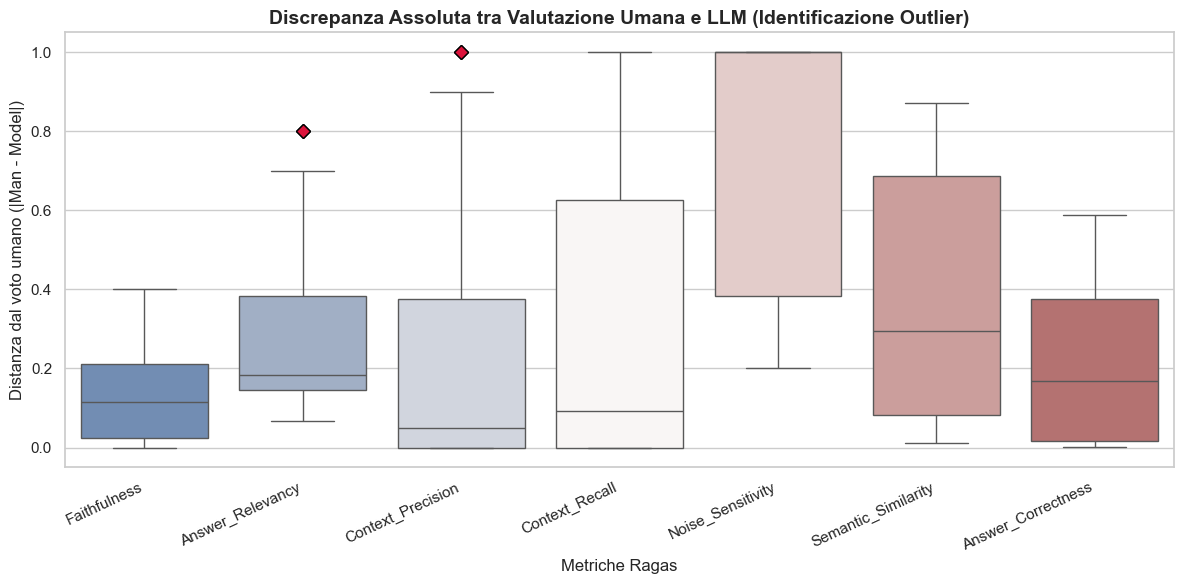

In [20]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    x="Metrica Ragas",
    y="Discrepanza Assoluta",
    data=df_melted,
    palette="vlag",
    fliersize=7,
    flierprops={
        "marker": "D",
        "markerfacecolor": "crimson",
        "markeredgecolor": "black",
    },
)

plt.xticks(rotation=25, ha="right")
plt.title(
    "Discrepanza Assoluta tra Valutazione Umana e LLM (Identificazione Outlier)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Metriche Ragas", fontsize=12)
plt.ylabel("Distanza dal voto umano (|Man - Model|)", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.tight_layout()

# plt.savefig("risultati/AETERNA/box_plot_discrepanze_real.png", dpi=300)
plt.show()

In [21]:
RISULTATI_BGE_M3 = "../risultati_BGE_M3.csv"

In [24]:
df_gpt_eval = clear_csv(RISULTATI_BGE_M3)
# print(df_gpt_eval.head(50))
df_gpt_eval.drop("Question", axis=1, inplace=True)
df_gpt_eval = df_gpt_eval.add_suffix("_model")

In [25]:
df = pd.merge(df_manuale, df_gpt_eval, left_on="ID_man", right_on="ID_model")

In [26]:
for col in METRICS:
    s1 = df[f"{col}_man"]
    # s1 = df[f"{col}_model_2"]
    s2 = df[f"{col}_model"]
    mask = s1.notna() & s2.notna()
    s1_clean, s2_clean = s1[mask], s2[mask]
    if len(s1_clean) > 2:
        mae = mean_absolute_error(s1_clean, s2_clean)
        spearman = spearmanr(s1_clean, s2_clean).correlation
        rmse = root_mean_squared_error(s1_clean, s2_clean)
        c1 = (s1_clean * 5).round().astype(int)
        c2 = (s2_clean * 5).round().astype(int)
        if c1.nunique() > 1 or c2.nunique() > 1 or (c1 != c2).any():
            cohen = cohen_kappa_score(c1, c2, labels=list(set(c1).union(set(c2))))
            cohen_str = f"{cohen:.4f}"
        else:
            cohen_str = "Incalcolabile => Varianza Zero"
        print(
            f"{col}: righe valutate = {len(s1_clean)}, MAE = {mae:.4f}, Spearman = {spearman:.4f}, Cohen = {cohen_str}, RMSE = {rmse:.4f}"
        )
    else:
        print(
            f"{col}: righe valutate = {len(s1_clean)} => Troppi pochi dati per la valutazione"
        )

Faithfulness: righe valutate = 20, MAE = 0.1512, Spearman = 0.7968, Cohen = 0.3413, RMSE = 0.2034
Answer_Relevancy: righe valutate = 20, MAE = 0.2533, Spearman = -0.1158, Cohen = 0.0511, RMSE = 0.3010
Context_Precision: righe valutate = 20, MAE = 0.2567, Spearman = 0.7277, Cohen = 0.3333, RMSE = 0.4158
Context_Recall: righe valutate = 20, MAE = 0.3052, Spearman = 0.3389, Cohen = 0.3590, RMSE = 0.5098
Noise_Sensitivity: righe valutate = 20, MAE = 0.7777, Spearman = -0.6781, Cohen = -0.1396, RMSE = 0.8318
Semantic_Similarity: righe valutate = 20, MAE = 0.4865, Spearman = 0.6056, Cohen = -0.0160, RMSE = 0.5603
Answer_Correctness: righe valutate = 20, MAE = 0.2064, Spearman = 0.8040, Cohen = 0.1824, RMSE = 0.2490


In [27]:
df_errori = pd.DataFrame()

for col in METRICS:
    df_errori[col] = (df[f"{col}_man"] - df[f"{col}_model"]).abs()

if "question" in df.columns:
    df_errori["question"] = df["question"]

available_metrics = [col for col in METRICS if col in df_errori.columns]

df_melted = df_errori.melt(
    id_vars=["question"] if "question" in df_errori.columns else [],
    value_vars=available_metrics,
    var_name="Metrica Ragas",
    value_name="Discrepanza Assoluta",
)

C:\Users\Gabriele\AppData\Local\Temp\ipykernel_3856\263982384.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


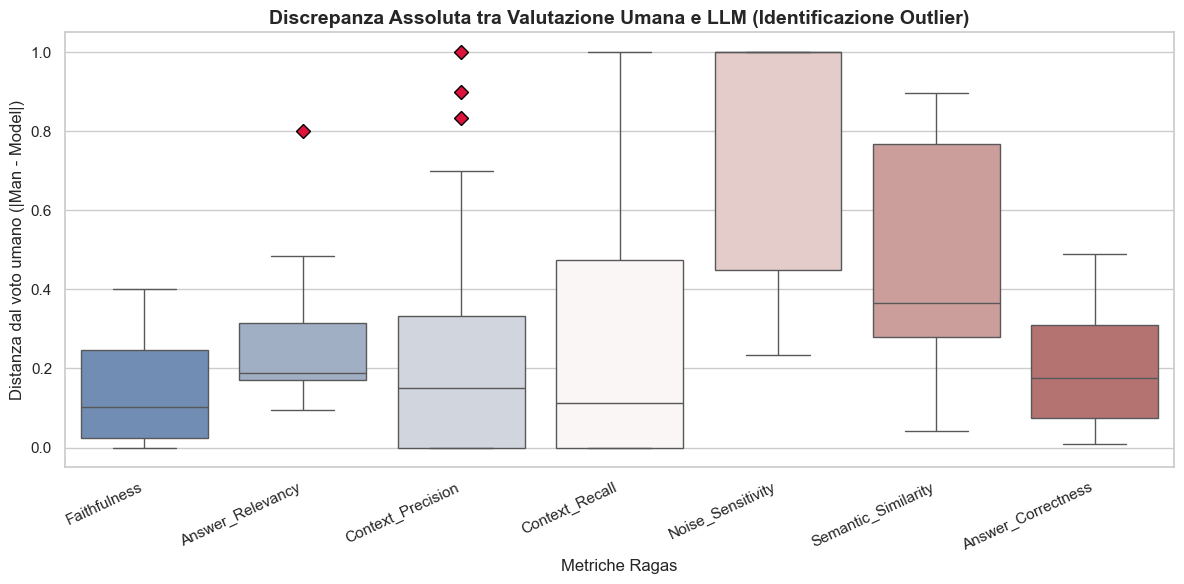

In [28]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    x="Metrica Ragas",
    y="Discrepanza Assoluta",
    data=df_melted,
    palette="vlag",
    fliersize=7,
    flierprops={
        "marker": "D",
        "markerfacecolor": "crimson",
        "markeredgecolor": "black",
    },
)

plt.xticks(rotation=25, ha="right")
plt.title(
    "Discrepanza Assoluta tra Valutazione Umana e LLM (Identificazione Outlier)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Metriche Ragas", fontsize=12)
plt.ylabel("Distanza dal voto umano (|Man - Model|)", fontsize=12)
plt.ylim(-0.05, 1.05)
plt.tight_layout()

# plt.savefig("risultati/AETERNA/box_plot_discrepanze_real.png", dpi=300)
plt.show()